# Semestrální projekt 3

In [39]:
.libPaths("C:/Users/kulka/OneDrive/Skola/BI-PRS/package") 

#install.packages("eurostat")
#install.packages("ggplot2")
#install.packages("vtable")
#install.packages('cowplot')
#install.packages('psych')
#install.packages('dplyr')
#install.packages('DescTools')
#install.packages('MESS') # gkgamma
#install.packages("ggpubr") # ggdensity
library(ggpubr)

#install.packages("lmtest") # dwtest
library(lmtest)

#install.packages("tseries") # jarque.bera.test
library("tseries")

#install.packages("polycor") # biserial.cor
library("polycor")

#install.packages("ltm") # biserial.cor
library("ltm")

#install.packages("Sleuth2") # data
library(Sleuth2)

#install.packages("olsrr")
library(olsrr)

#install.packages("car")
library(car)

#install.packages("MASS")
library(MASS)

#install.packages("sfsmisc")
library(sfsmisc)

#install.packages("IRdisplay") # display_png
library(IRdisplay)

#install.packages("rcompanion")
library(rcompanion)

library(MESS)
library(DescTools)
library(dplyr)
library(psych)  
library(kableExtra)
library(moments)
library(cowplot)
library(eurostat)
library(ggplot2)
library(vtable)
library(corrplot)
library(e1071)

In [2]:
K = 11
L = 5 
((K+L)*47)%%(11)+1
2011 + ((K+L)*47)%%(11)+1

[1] 5

[1] 2016

## Popis a zkoumaní dat
Data si prozkoumám a budu se snažit najít údaje které by mohli nejvíce ovlivňovat HDP na osobu.

In [3]:
data = get_eurostat("nama_10_pc")

# V datech chybí údaje pro Bosna a Hercegovina a Kosovo
gdp_data <- data[data$TIME_PERIOD=='2016-01-01',] 
gdp_data <- gdp_data[gdp_data$unit=='CP_EUR_HAB',] # vyjádření v eurech na obyvatele
gdp_data <- gdp_data[gdp_data$na_item=='B1GQ',] # výpočet v tržních cenách

# Odstraněni souhrnů
gdp_data <- gdp_data[!gdp_data$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ]

gdp_data$TIME_PERIOD = NULL
gdp_data$na_item = NULL
gdp_data$unit = NULL
gdp_data$freq = NULL

Table nama_10_pc cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/600a9a0f1d1e6437bfe6f70a0b752b90.rds



Variable,Mean,Sd,Min,Pctile[25],Median,Pctile[75],Max,IQR,Skewness,Kurtosis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
values,31539,29094,3730,11850,22330,40920,147270,29070,2,4.8


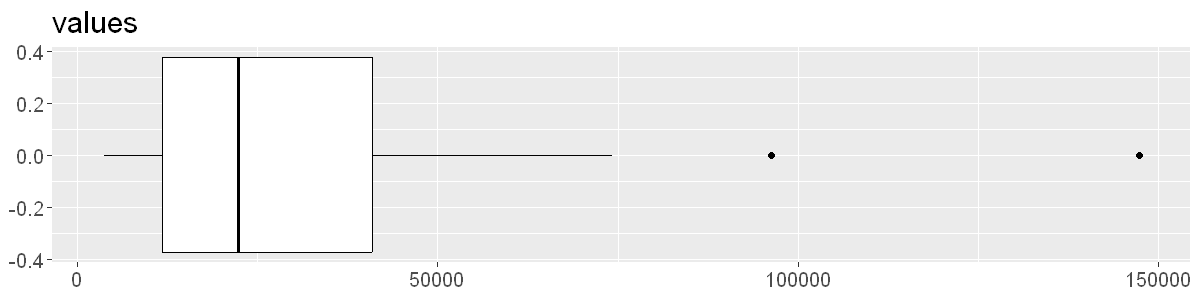

In [4]:
options(repr.plot.width = 10, repr.plot.height = 2.5)

summ <- c('mean(x)', 'sd(x)', 'min(x)', 'pctile(x)[25]', 
          'median(x)', 'pctile(x)[75]', 'max(x)', 'IQR(x)',
          'skewness(x)', 'kurtosis(x)')

sumtable(gdp_data, out="return", summ=summ)

ggplot(gdp_data, aes(x=values)) +
        ggtitle("values") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

Vysoká směrodatná odchylka a kladná šikmost indikují značné rozdíly v HDP na obyvatele mezi evropskými zeměmi. 
Vysoké maximum a špičatost naznačují, že několik zemí s vysokými hodnotami HDP na obyvatele významně ovlivňuje rozdělení, takže průměr je vyšší než medián. To naznačuje, že více než polovina zemí má hodnoty HDP na obyvatele pod průměrem a tedy se nejedná o normální rozdělení.

Tyto statistiky poukazují na ekonomickou rozmanitost napříč evropskými zeměmi a přítomnost několika zemí s vysokým HDP na obyvatele, které významně ovlivňují celkové rozdělení. Podívám se proto na outliery.

In [5]:
head(gdp_data[order(gdp_data$values, decreasing = TRUE), ], 2)

geo,values
<chr>,<dbl>
LI,147270
LU,96230


Outliery jsou: <br>
Lichtenštejnsko <br>
Lucembursko <br>

Obe tyhle země jsou velice malé s nízkým počtem obyvatel. Takové země mohou být efektivnější v přidělovaní zdrojů, jako například přístup ke vzdělání, zdravotní péči a infrastruktuře, což může vést k vyšší úrovni produktivity. Nebo mohou taky lépe specializovat svá odvětí a sektory které jsou ziskové. 

Obe země se taky často považují za daňové ráje, co může navýšit HDP. Vyzkouším zjistit, jestli je to pravda. Podívám se jakou část tvoří finanční odvětí z celkového HDP země a taky na PFDI (PZI - Přímé zahraniční investice).

In [6]:
data_gdp_ind = get_eurostat("nama_10_a10") # HDP podle odvětví A*10

data_gdp_ind = data_gdp_ind[data_gdp_ind$TIME_PERIOD=='2016-01-01',]
data_gdp_ind = data_gdp_ind[data_gdp_ind$unit=='CP_MEUR',] # aktuální cena, milion eur
data_gdp_ind = data_gdp_ind[data_gdp_ind$na_item=='B1G',] # hrubá hodnota 
data_gdp_ind = data_gdp_ind[!data_gdp_ind$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ] # Odstraněni souhrnůzzzz

data_gdp_ind_fin = data_gdp_ind[data_gdp_ind$nace_r2=='K',] # finanční a pojišťovací činnost
data_gdp_ind_tot = data_gdp_ind[data_gdp_ind$nace_r2=='TOTAL',] # celkem

data_gdp_ind_fin$gdp_fin =  round (( data_gdp_ind_fin$values / data_gdp_ind_tot$values ) * 100, digits = 2)
data_gdp_ind_fin = select ( data_gdp_ind_fin, geo, gdp_fin )

##################################################################################

data_fdi = get_eurostat("tec00105") # Inward FDI stocks in % of GDP
data_fdi = data_fdi[data_fdi$TIME_PERIOD=='2016-01-01',]
data_fdi = select ( data_fdi, geo, values )

Table nama_10_a10 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/ebf501c2a41065e5554940eb3ac02c78.rds

Table tec00105 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/32dcc41658b82bad54b8b2267576b7df.rds



In [7]:
mer_data_fin = merge(x = data_gdp_ind_fin, y = data_fdi, by = "geo", all.x = TRUE)
names(mer_data_fin) <- c("geo", "FIN, % of GDP", "FDI, % of GDP")
head ( mer_data_fin[order(mer_data_fin$"FIN, % of GDP", decreasing = TRUE), ], 5)

,geo,"FIN, % of GDP","FDI, % of GDP"
,<chr>,<dbl>,<dbl>
23,LU,27.12,6435.6
21,LI,13.29,NA
6,CY,11.56,1938.9
17,CH,10.11,NA
27,MT,8.80,1530.9


FIN, % of GDP - kolik procent HDP pochází z finančního odvětí <br>
FDI, % of GDP - kolik procent HDP tvoří příliv přímých zahraničních investic <br>

Značná část HDP Lucemburska pochází z finančního odvětí (27.12 %) která je taky o dost vetší než u ostatních zemí. Lucemburské přímé zahraniční investice (6 435.6 %) jsou velice vysoké. Ukazuje to na velký přiliv zahraničních investic. <br>Lichtenštejnsko má také relativně vysoké procento HDP z finančního odvětí (13.29 %). FDI hodnota chybí ale velikost jeho finančního odvětí je vetší, než jiné známe daňové ráje (Kypr, Švýcarsko, Malta). <br> Data naznačují, že obě země by se mohli považovat za daňové ráje. To by mohlo vysvětlit jejich vysoké HDP na osobu a důvod proč tvoří outlety.

## Volba regresoru
### Populace a HDP

U outlieru jsem mluvil, jak země s menší populaci mohou mít potenciálně lepší kontrolu nad svými zdroji a specializaci. Chci si tenhle vztah a ověřit a zjistit jestli bych ho mohl potenciálně použit velikost populace jako regresor. Pro výpočet HDP na obyvatele je populace použita přímo s HDP země, proto se podívam taky na HDP.<br>
K datum si přidám údaje o populaci a HDP. Budu zkoumat jestli země s vysokou populaci mají menší HDP na obyvatele zatím co země s nízkou populací vyšší. Nejdříve se podívám na mapu zemí a krajní hodnoty. Pomoci map si budu moc vytvořit základný přehled o zemích a zároveň je vzájemně porovnat.

In [8]:
data_pop = get_eurostat("tps00001") # Population on 1 January
data_pop = data_pop[data_pop$TIME_PERIOD=='2016-01-01',]
data_pop = select ( data_pop, geo, values ) 
names(data_pop) <- c("geo", "population")

data_gdp = get_eurostat("nama_10_gdp") # GDP and main components (output, expenditure and income)
data_gdp = data_gdp[data_gdp$TIME_PERIOD=='2016-01-01',]
data_gdp = data_gdp[data_gdp$na_item=='B1GQ',] # výpočet v tržních cenách
data_gdp = data_gdp[data_gdp$unit=='CP_MEUR',] # aktuální ceny, miliony eur
data_gdp <- data_gdp[!data_gdp$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ] # Odstraněni souhrnů
data_gdp = select ( data_gdp, geo, values )
names(data_gdp) <- c("geo", "gdp")

Table tps00001 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/5f0f24f87be1fb88b5f525ca2d3fca7c.rds

Table nama_10_gdp cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/dde0fde3c54b5821c5fef032c0f5a9cb.rds



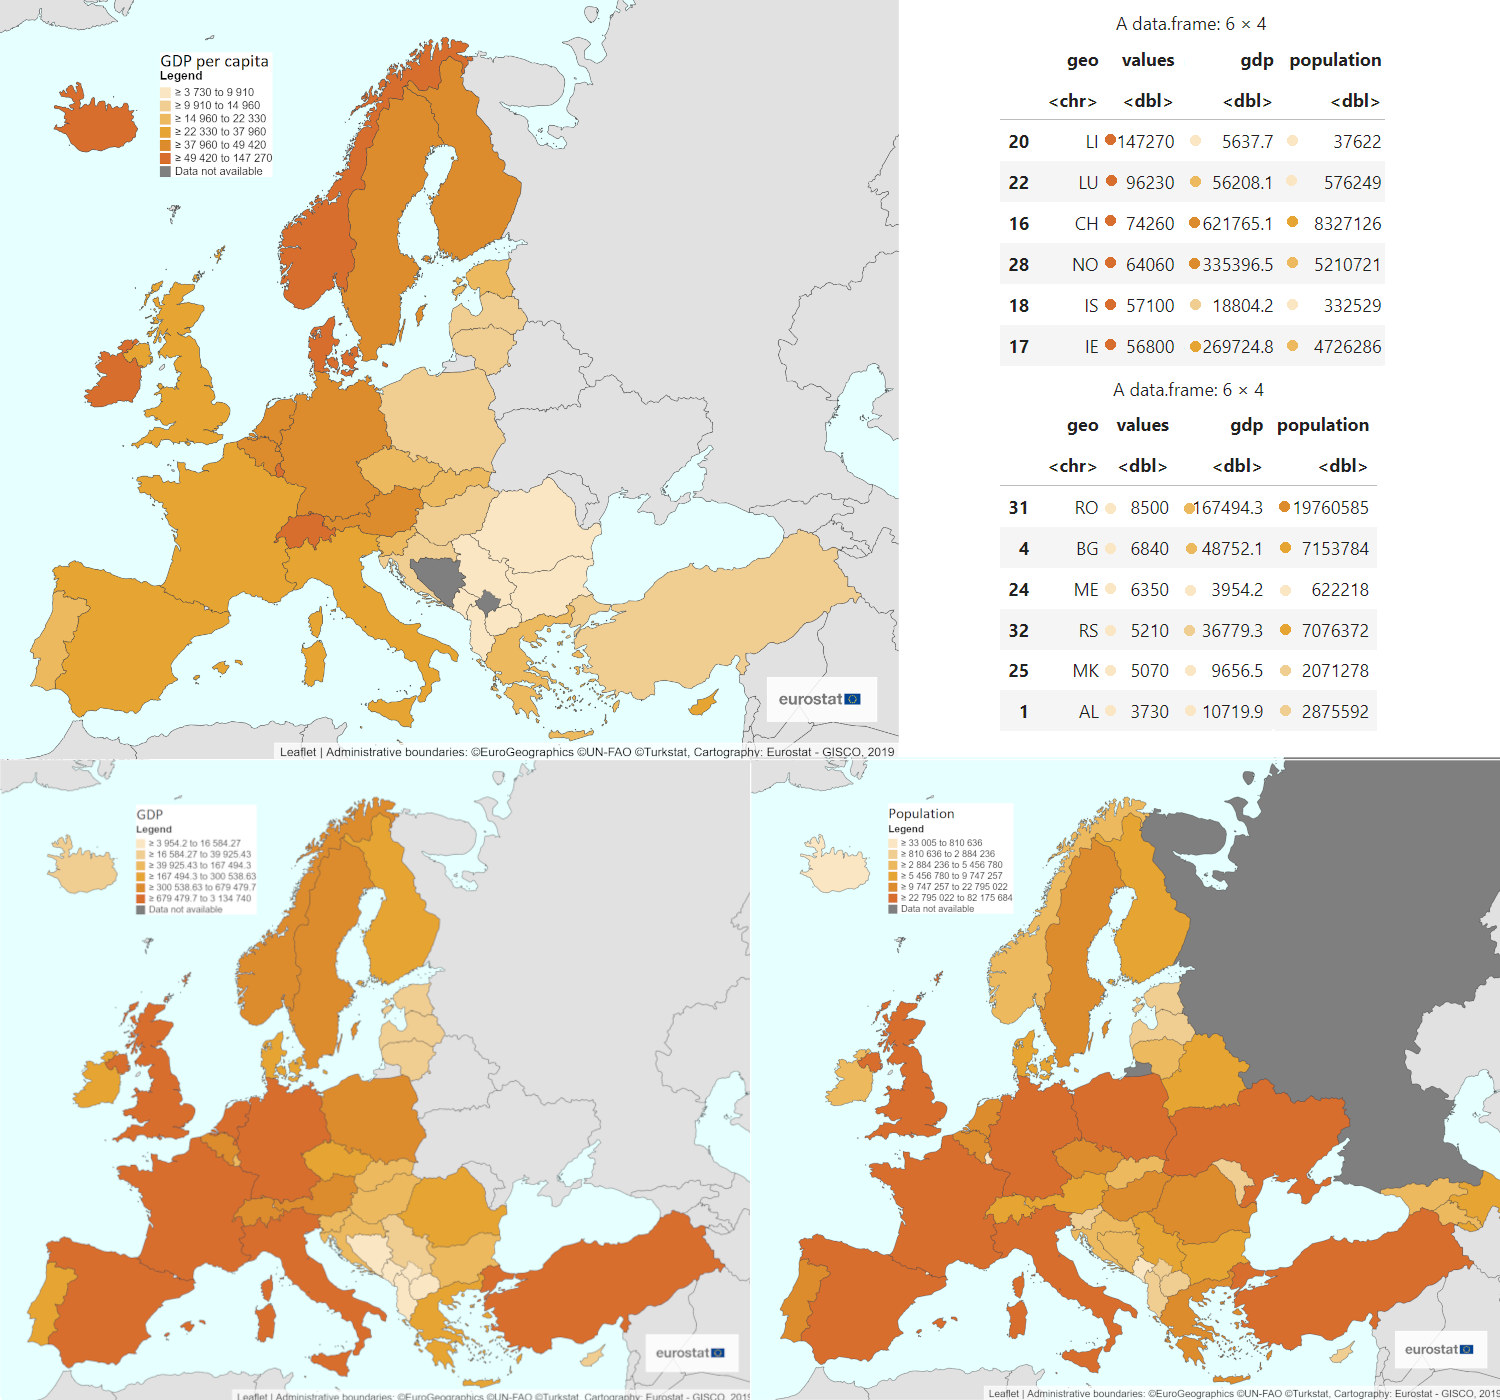

In [9]:
mer_data = merge(x = gdp_data, y = data_pop, by = "geo", all.x = TRUE)
mer_data = merge(x = mer_data, y = data_gdp, by = "geo", all.x = TRUE)

# Hodnoty jsou v obrázku pro lepší zpřehlednění
#head(mer_data[order(mer_data$values, decreasing = TRUE), ], 6)
#tail(mer_data[order(mer_data$values, decreasing = TRUE), ], 6)

display_png(file = "pic01_kulkaja1.png")

Země s nejvyšším HDP na obyvatele jsou: &emsp;Země s nejnižším HDP na obyvatele jsou:<br>
Lichtenštejnsko &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Albánie<br>
Lucembursko &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp;&nbsp;&nbsp; Severní Makedonie <br>
Švýcarsko &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp;&nbsp; Srbsko<br>
Nórsko &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp;&nbsp; Černá Hora<br>
Island &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Bulharsko<br>
Irsko &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp;&nbsp; Rumunsko<br>

Vztah asi nebude platit. Vidím tři země (Albánie, Severní Makedonie a Černá Hora), které napříč nízké populaci mají nízké HDP na obyvatele. Švýcarsko taky, které má trochu vyšší populaci a zároveň má vysoké HDP na obyvatele. To stejné platí i pro HDP. Země, které mají vysoké HDP mohou mít nízké HDP and obyvatele (Polsko, Portugalsko) a zároveň platí opak, země s nízkým HDP mající vysoké HDP na obyvatele (Lichtenštejnsko, Island).<br>
Podívám se taky na korelaci a scatter plot abych vztah viděl na všech zemích zároveň. Korelace a scatter plot mi napoví, číselné i graficky, jestli existuje lineární vztahy mezi veličinami.

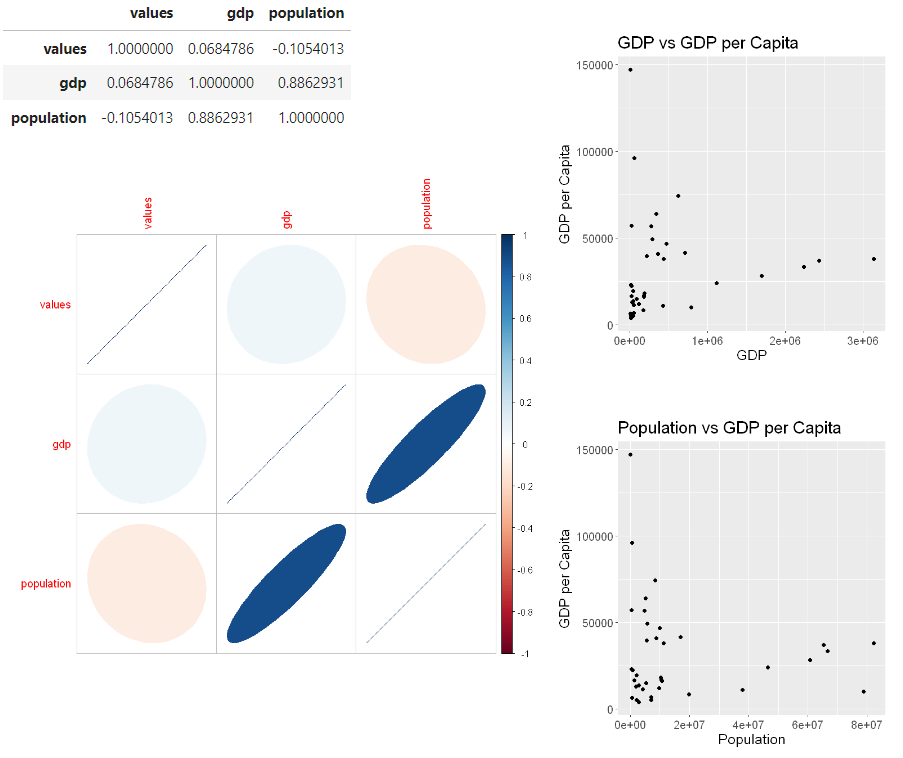

In [10]:
g1 = ggplot(mer_data, aes(x = population, y = values)) +
      geom_point() +
      theme(text = element_text(size = 15)) +
      labs(title = "Population vs GDP per Capita",
           x = "Population",
           y = "GDP per Capita")

g2 = ggplot(mer_data, aes(x = gdp, y = values)) +
      geom_point() +
      theme(text = element_text(size = 15)) +
      labs(title = "GDP vs GDP per Capita",
           x = "GDP",
           y = "GDP per Capita")

options(repr.plot.width = 8, repr.plot.height = 8)
cor_gdp = cor(mer_data[c('values', 'gdp', 'population')])
#cor_gdp
#corrplot(cor_gdp, method="ellipse")

options(repr.plot.width = 10, repr.plot.height = 5)
#plot_grid(g1, g2, nrow=1)

display_png(file = "pic02_kulkaja1.png")

Korelační vztah HDP na obyvatele a populace je jenom -0.10 a ješte menší pro HDP 0.06. Scatter ploty poukazují na nelineární vztah. Oba výsledky ukazují, že jsou vztahy moc slabé. <br>
Protože se nejedná o lineární vztah, mužů se pokusit si data transformovat. Nejdříve se musím podívat jestli se jedná o ne normální rozdělení a pak pomocí boxcox zjistit vhodnou transformaci.

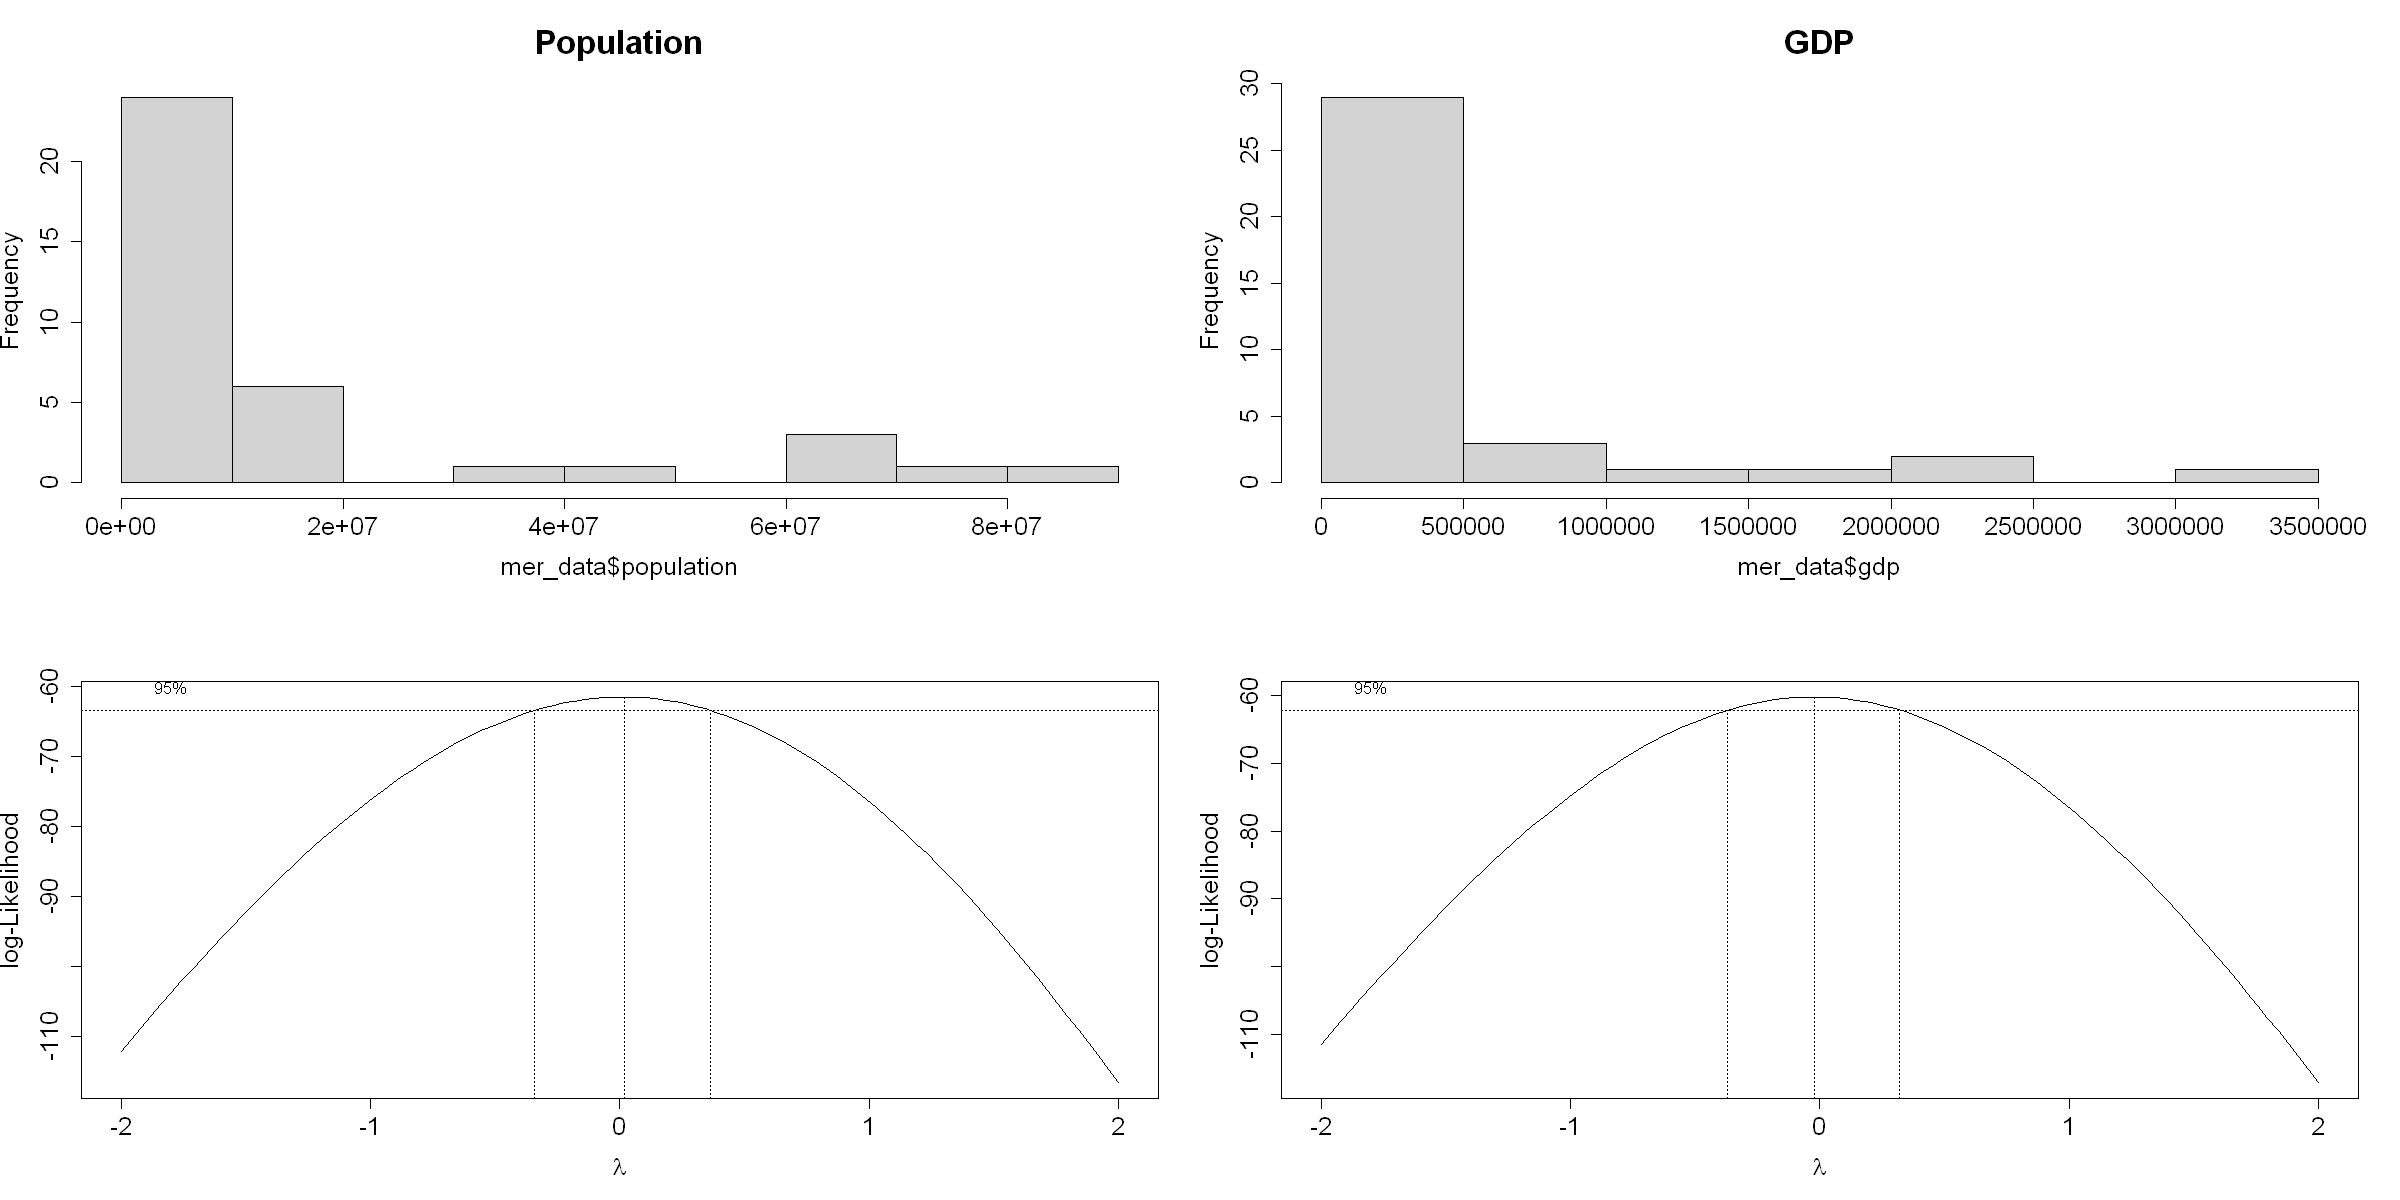

In [11]:
options(repr.plot.width = 20, repr.plot.height = 10)
par(cex.lab = 1.5,
    cex.main = 2,  
    cex.axis = 1.5,
    mfrow=c(2,2))    

hist(mer_data$population, main = "Population")
hist(mer_data$gdp, main = "GDP")
boxcox(lm(values~population, data = mer_data))
boxcox(lm(values~gdp, data = mer_data))

V obou případech se jedná o ne normální rozdělení a boxcox $\lambda$ je velice blízky nule, naznačující vhodnost logaritmické transformace. Vím, že HDP na osobu má taky ne normální rozdělení proto vyzkouším různé kombinace logaritmické transformace.

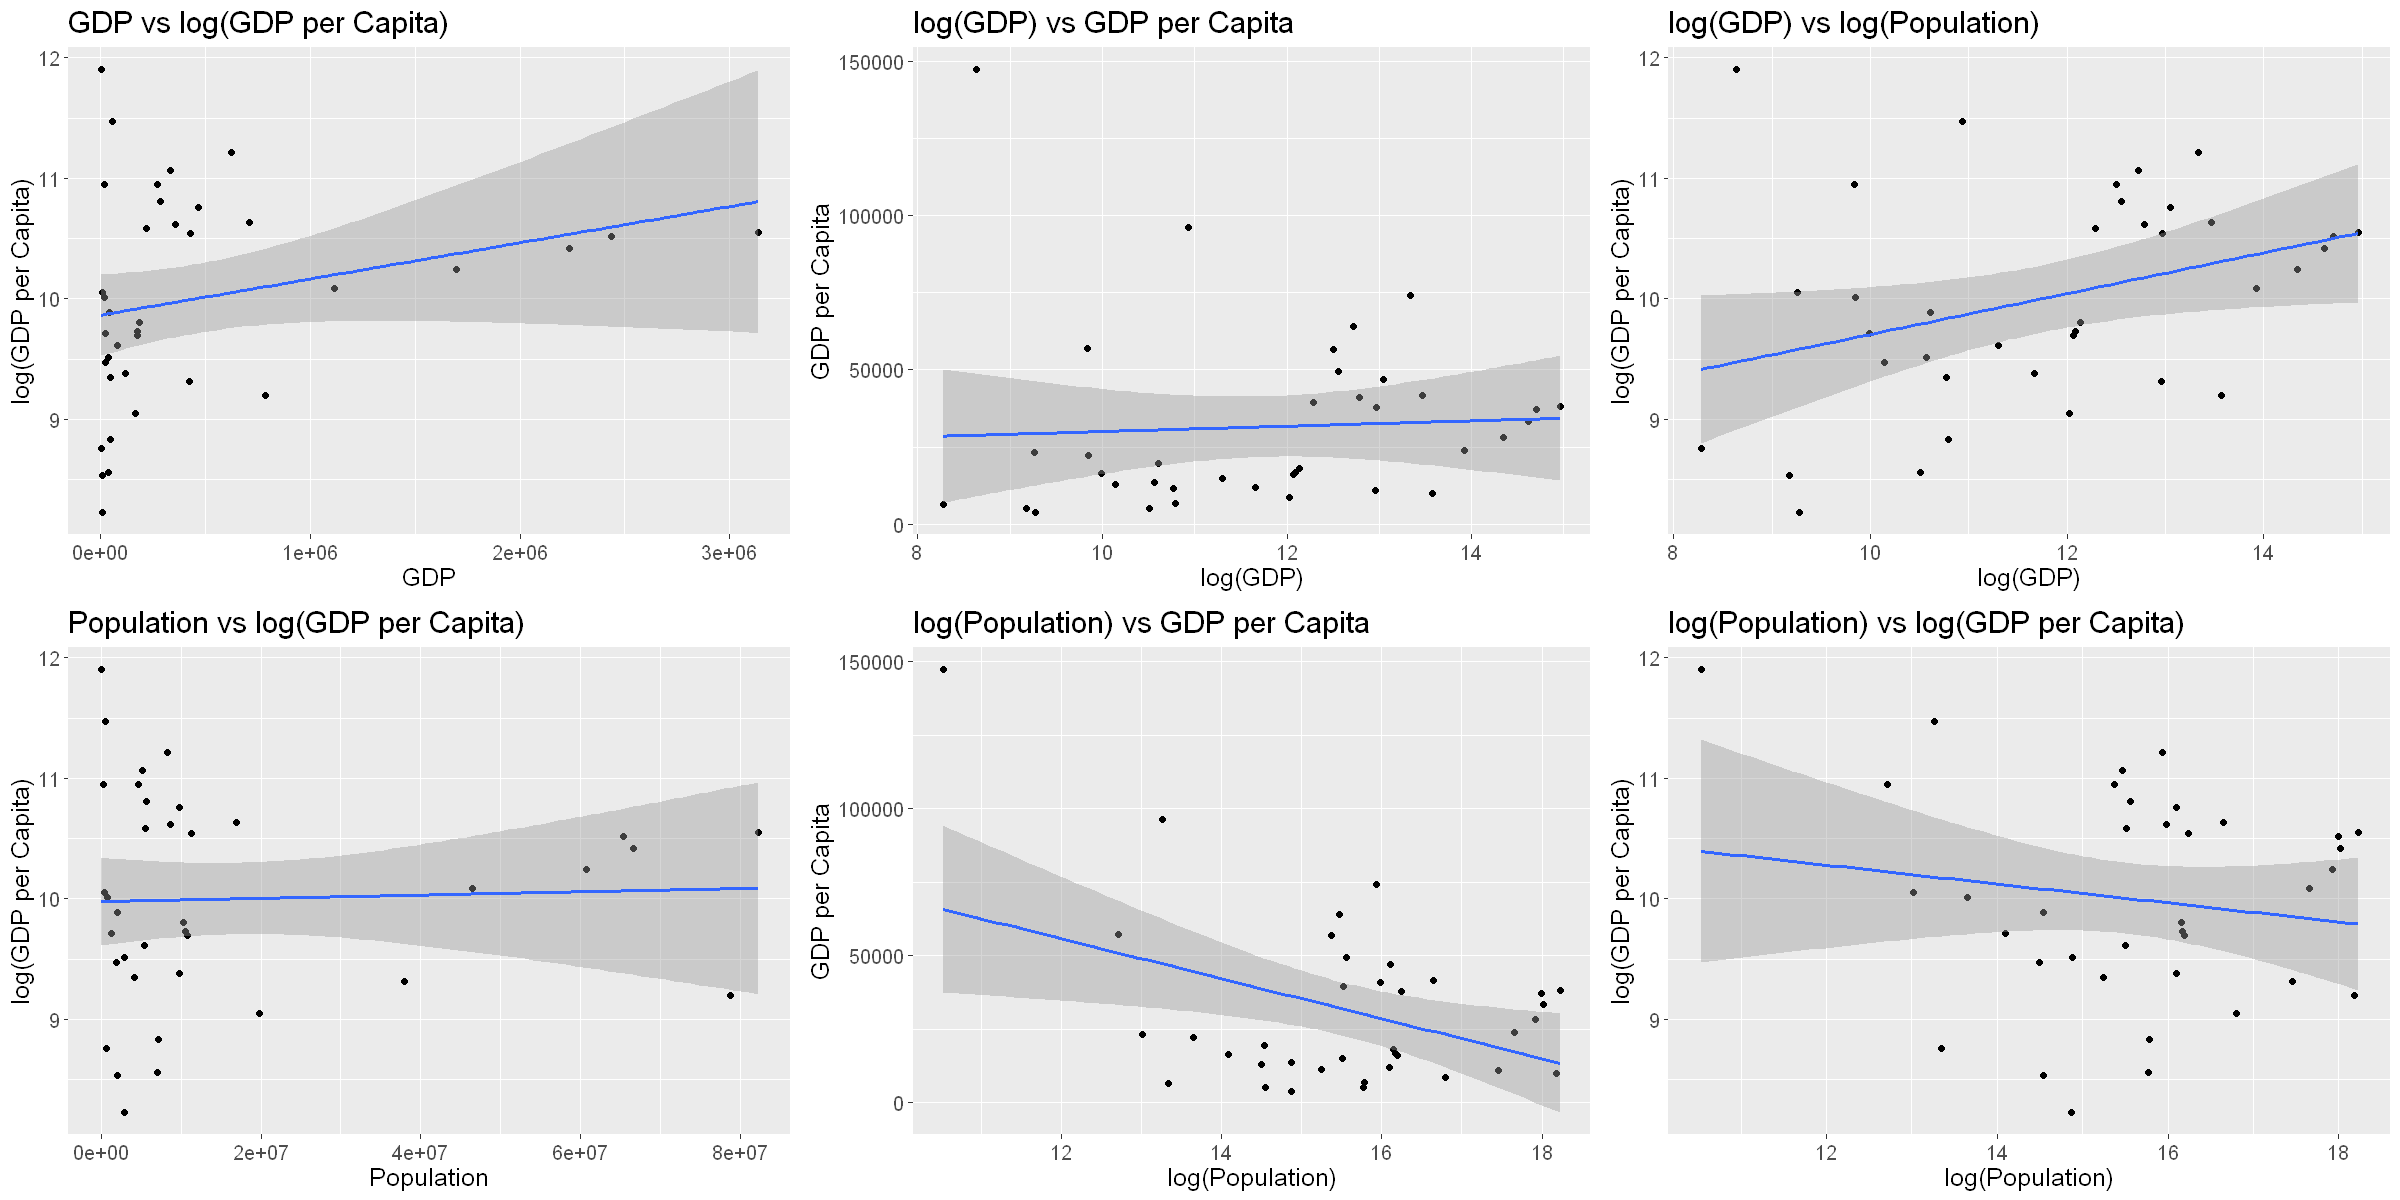

In [12]:
options(repr.plot.width = 20, repr.plot.height = 10)

g1 = ggplot(mer_data, aes(x = gdp, y = log(values))) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "GDP vs log(GDP per Capita)",
           x = "GDP",
           y = "log(GDP per Capita)")
g2 = ggplot(mer_data, aes(x = log(gdp), y = values)) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "log(GDP) vs GDP per Capita",
           x = "log(GDP)",
           y = "GDP per Capita")
g3 = ggplot(mer_data, aes(x = log(gdp), y = log(values))) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "log(GDP) vs log(Population)",
           x = "log(GDP)",
           y = "log(GDP per Capita)")

g4 = ggplot(mer_data, aes(x = population, y = log(values))) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "Population vs log(GDP per Capita)",
           x = "Population",
           y = "log(GDP per Capita)")
g5 = ggplot(mer_data, aes(x = log(population), y = values)) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "log(Population) vs GDP per Capita",
           x = "log(Population)",
           y = "GDP per Capita")
g6 = ggplot(mer_data, aes(x = log(population), y = log(values))) +
      geom_point() +
      stat_smooth(method="lm", formula=y~x) +
      theme(text = element_text(size = 15)) +
      labs(title = "log(Population) vs log(GDP per Capita)",
           x = "log(Population)",
           y = "log(GDP per Capita)")

plot_grid(g1, g2, g3, g4, g5, g6, nrow=2)

Ani po logaritmizaci nemám linearni vztah mezi HDP na osobu a populaci nebo HDP. 
Populaci a HDP proto nepoužiji jako regresory.

### Region
Při zobrazení mapy v předchozí sekci jsem si všimnul, že většina zemí na západní straně mají vyšší HDP na obyvatele než východní, proto si země rozdělím podle jejích polohy. Mohou, ale taky existovat jiné vztahy které země spojují (historie, kultura) a jsou dané jejich polohou. Vyzkouším si země kategorizovat i podle jazykových rodin.  

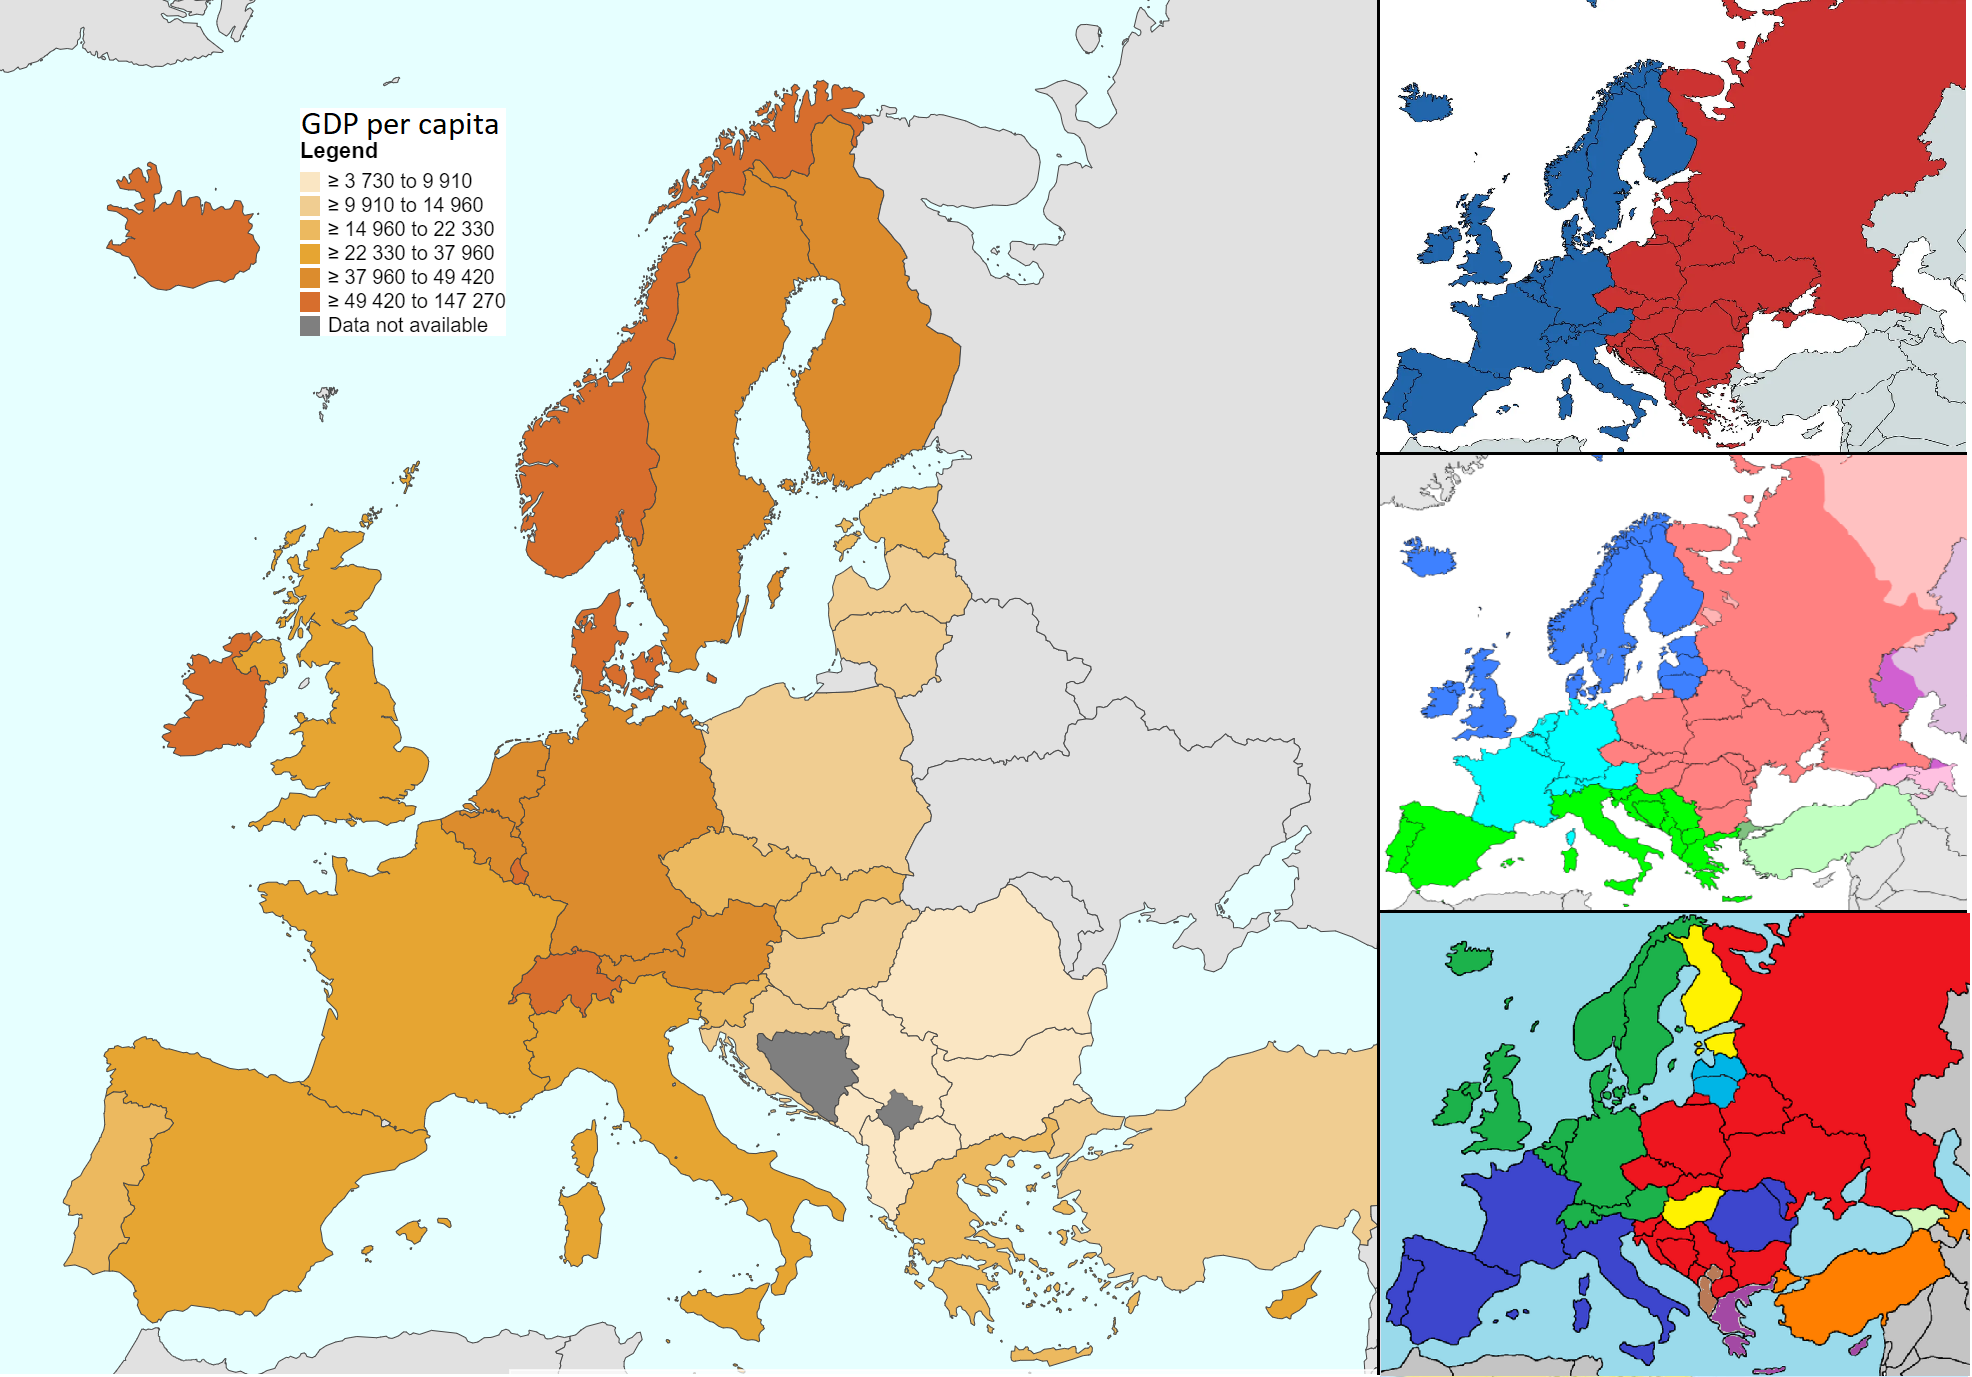

In [13]:
display_png(file = "pic03_kulkaja1.png")

In [14]:
reg_data = gdp_data

# EA - eastern, WE - western
reg_data$region = c('EA', 'WE', 'WE', 'EA', 'WE', 'EA', 'EA', 'WE', 'WE', 'EA',
                    'EA', 'WE', 'WE', 'WE', 'EA', 'EA', 'WE', 'WE', 'WE', 'WE', 
                    'EA', 'WE', 'EA', 'EA', 'EA', 'WE', 'WE', 'WE', 'EA', 'EA',
                    'EA', 'EA', 'WE', 'EA', 'EA', 'EA', 'WE')
  
# AL - albanian, BA - baltic, FU - finno-ugric, GE - germanic, HE - hellenic, IE - indo-european, RO - romance, SL - slavic, TU - turkish, OT - other
# IE = AL + HE + BA
# OT = FU + TU
reg_data$language =  c('IE', 'GE', 'GE', 'SL', 'GE', 'IE', 'SL', 'GE', 'GE', 'OT', 
                       'IE', 'RO', 'OT', 'RO', 'SL', 'OT', 'GE', 'GE', 'RO', 'GE', 
                       'IE', 'GE', 'IE', 'SL', 'SL', 'RO', 'GE', 'GE', 'SL', 'RO',
                       'RO', 'SL', 'GE', 'SL', 'SL', 'OT', 'GE')

# reg_data$reg =  c('AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 
#                   'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LI', 
#                   'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT',
#                   'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'UK')

Rozdelení podle polohy:<br>
Prvotní rozdělení na východ a západ bylo nejlepší. Vetší rozdělení přinášelo horši výsledky.

Rozdelení podle jazyka:<br>
Snažil jsem se získat co nejlepší poměr mezi výsledky a smysluplným rozdělením. Detailnejší rozdelení ma slabší výsledky, zatím co menší ma lepší výsledky ale rozdelení není moc logické.

Teď se podívám, které rozdělení je lepší. Podívám se jestli existuje korelace, jestli existuje statistický rozdíl mezi regiony/jazyky a které lépe popisuje HDP na obyvatele.

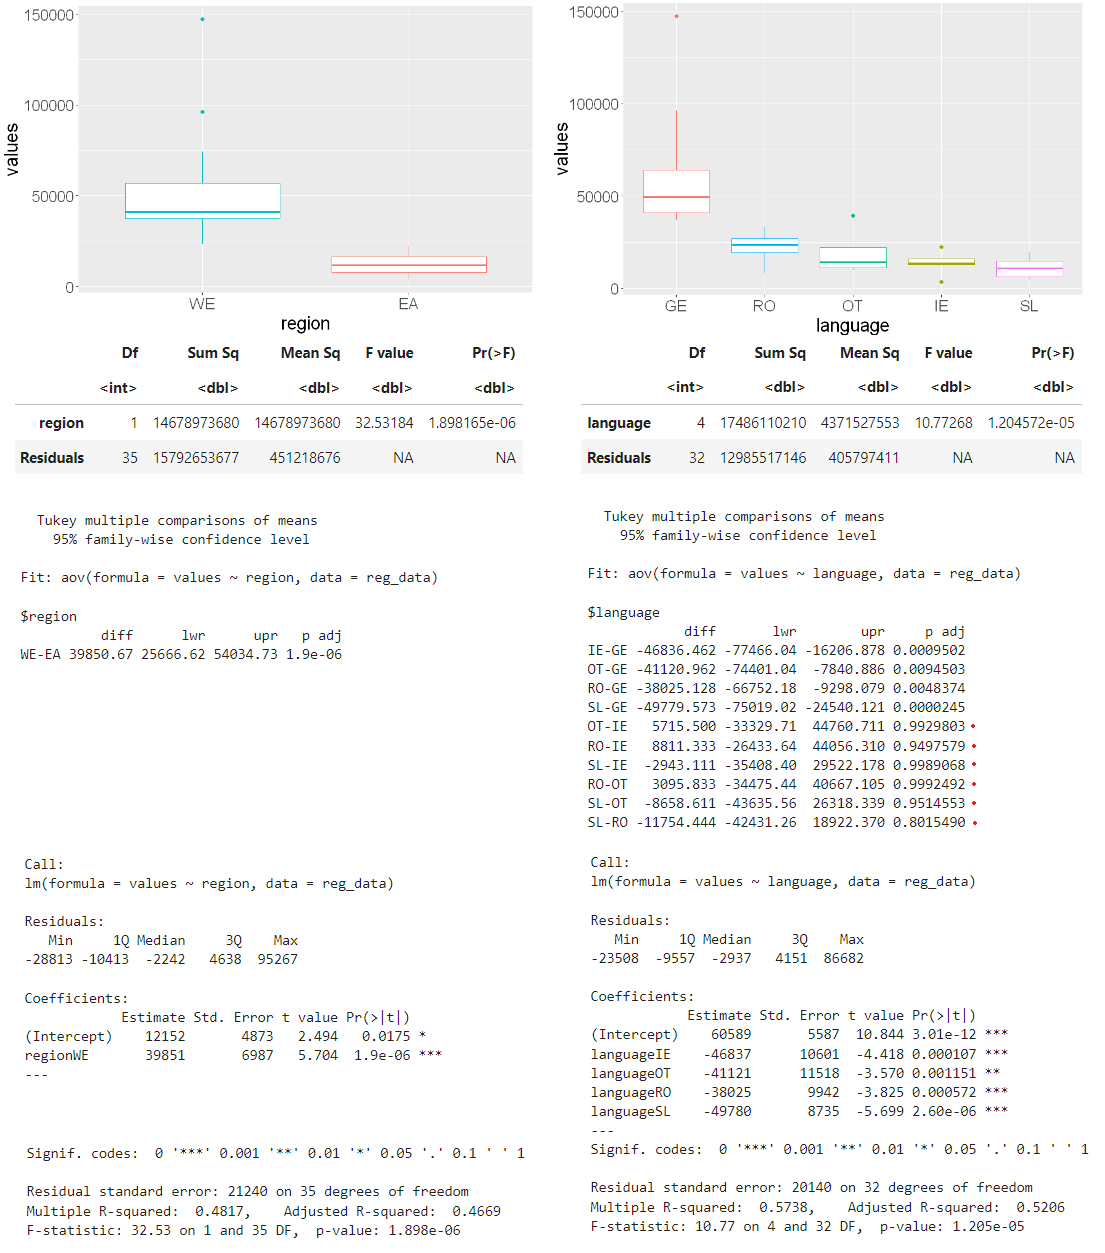

,df,AIC,BIC
,<dbl>,<dbl>,<dbl>
fitRE,3,846.2615,851.0942
fitLA,6,845.0202,854.6857


In [15]:
options(repr.plot.width = 8, repr.plot.height = 5)

# ggplot(reg_data, aes(x=region, y=values, color=region)) +
#     geom_boxplot(show.legend=F) +
#     scale_x_discrete(limits = c("WE", "EA")) +
#     theme(text = element_text(size = 20))
# anova(aov(values ~ region, data = reg_data))
# TukeyHSD(aov(values ~ region, data = reg_data))
 fitRE = lm(values ~ region, data = reg_data)
# summary(fitRE)

# ggplot(reg_data, aes(x=language, y=values, color=language)) +
#     geom_boxplot(show.legend=F) +
#     scale_x_discrete(limits = c("GE", "RO", "OT", "IE", "SL")) +
#     theme(text = element_text(size = 20))
# anova(aov(values ~ language, data = reg_data))
# TukeyHSD(aov(values ~ language, data = reg_data))
 fitLA = lm(values ~ language, data = reg_data)
# summary(fitLA)

# Spojení pro lepší přehled
display_png(file = "pic04_kulkaja1.png")

fit_AIC = AIC(fitRE, fitLA)
fit_BIC = BIC(fitRE, fitLA)
fit_BIC$df = NULL
cbind( fit_AIC, fit_BIC )

Podle box plotu u obou rozdělení existuje korelace k HDP na obyvatele. U regiónu je zjevná zatím co u jazyku je slabší.<br>
Oba rozdělení mají statistický významný rozdíl mezi svými kategoriemi (anova). Regiony jsou na tom ale lépe (TukeyHSD), některé kombinace koeficientu nemají totiž statistický významný vliv.<br>
Všechny koeficienty u obou rozděleni jsou významné, mají podobnou chybu, podobné jsou i hodnoty Multiple $R^2$ a Adjusted $R^2$ a modely jsou statistické významné. Jediný rozdíl je, že jazyky (57.38 %) vysvětluji HDP na obyvatele lépe než regiony (48.17 %).<br>
Informační zisk máji rozdělení téměř stejný, ale rozdělení podle jazyku je 2x složitější. <br>

I když rozdělení podle jazyku lépe popisuje HDP na obyvatele, použiji regióny. Mají lepší korelaci a jsou jednoduchší.

In [16]:
gdp_data$region = c('EA', 'WE', 'WE', 'EA', 'WE', 'EA', 'EA', 'WE', 'WE', 'EA',
                    'EA', 'WE', 'WE', 'WE', 'EA', 'EA', 'WE', 'WE', 'WE', 'WE', 
                    'EA', 'WE', 'EA', 'EA', 'EA', 'WE', 'WE', 'WE', 'EA', 'EA',
                    'EA', 'EA', 'WE', 'EA', 'EA', 'EA', 'WE')

### Spotřeba v domácnosti

Spotřeba domácností dobře odráží životní úroveň. Vyšší spotřeba domácností pak ukazuje na vyšší disponibilní příjem a ekonomickou prosperitu, což vede k vyššímu HDP na obyvatele. Provedu základní analýzu dat, korelaci a rozdělení.

In [17]:
data_cons = get_eurostat("hbs_exp_t111") # Mean consumption expenditure per household and per adult equivalent

data_cons = data_cons[data_cons$TIME_PERIOD=='2015-01-01',] # roky jsou 2020, 2015, 2010, ...
data_cons = data_cons[data_cons$unit=='EUR_AE',] # eura na dospelého
data_cons = data_cons[!data_cons$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ]

data_cons = select ( data_cons, geo, values ) 
names(data_cons) = c("geo", "consumption")
gdp_data = merge(x = gdp_data, y = data_cons, by = "geo", all.x = TRUE)

head(gdp_data)

Table hbs_exp_t111 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/328cbcc861afee53177853360d1662b5.rds



,geo,values,region,consumption
,<chr>,<dbl>,<chr>,<dbl>
1,AL,3730,EA,NA
2,AT,40920,WE,23590
3,BE,37960,WE,23799
4,BG,6840,EA,3671
5,CY,22330,EA,17717
6,CZ,16790,EA,6061


Variable,Mean,Sd,Min,Pctile[25],Median,Pctile[75],Max,IQR,Skewness,Kurtosis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
consumption,14408,9806,2425,6073,12236,22844,38424,16771,0.59,-0.69


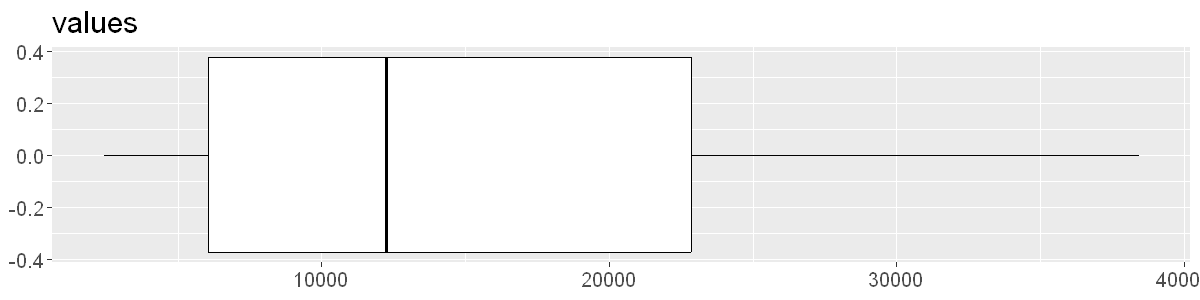

In [18]:
options(repr.plot.width = 10, repr.plot.height = 2.5)

sumtable(data_cons, out="return", summ=summ)

ggplot(data_cons, aes(x=consumption)) +
        ggtitle("values") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

Průměr ukazuje, že průměrná spotřeba domácností je kolem 14 408 eur. Medián naznačuje ale, že polovina míň než 12 236 eur, co je taky následkem kladné šikmosti.<br>
Vysoká směrodatná odchylka (9 806 eur) ukazuje na velké rozdíli ve spotřebe domácností.<br>
Kladná šikmost (0,59) indikuje více domácností s nižšími hodnotami spotřeby a méně domácností s velmi vysokou spotřebou.<br>
Data nemají outliery.

,values,consumption
values,1.000000,0.952495
consumption,0.952495,1.000000



	Shapiro-Wilk normality test

data:  gdp_data$consumption
W = 0.90946, p-value = 0.009457


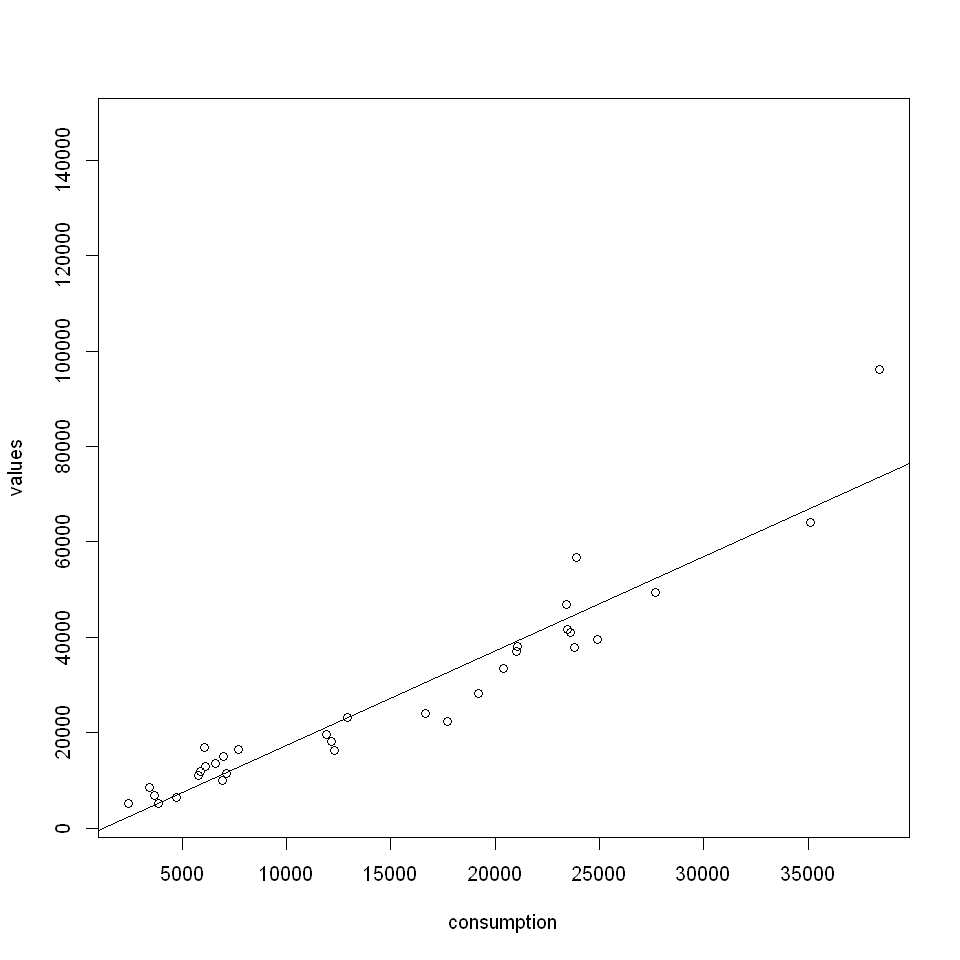

In [19]:
options(repr.plot.width = 8, repr.plot.height = 8)
gdp_data_NA <- na.omit(gdp_data) # musím zhodit prázdne údaje jinak nebude fungovat výpočet korelace

cor(gdp_data_NA[c('values', 'consumption')])

plot(values~consumption, data = gdp_data)
abline(lm(values~consumption, data = gdp_data))
shapiro.test(gdp_data$consumption)

Velice velká korelace (0.95) mezi spotřebou v domácnosti a HDP na obyvatele ukazuje na silný lineární vztah mezi nimi. Tudiž vetší spotřeba v domácnosti temeř přímo odpovída vyššímu HDP na obyvatele. U vysoké korelace můžeme pomocí jednoduché lineární regresi dobře popsat vysvětlovanou proměnou, ale u predikcí nemusí mít dobré odhady a v modelech s více regresormi se model muže soustředit převážné jenom na tenhle regresor. <br>
Shapiro-Wilk test vyšel 0.009 a normalitu zamítáme. <br>

In [20]:
summary(lm(values~consumption, data=gdp_data))


Call:
lm(formula = values ~ consumption, data = gdp_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-10323.6  -3352.3   -652.6   2895.5  22611.2 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2396.4552  1999.7165  -1.198     0.24    
consumption     1.9783     0.1136  17.413   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6257 on 31 degrees of freedom
  (4 observations deleted due to missingness)
Multiple R-squared:  0.9072,	Adjusted R-squared:  0.9043 
F-statistic: 303.2 on 1 and 31 DF,  p-value: < 2.2e-16


Spotřeba má statisticky významný vliv (2$e^{-16}$) na HDP na obyvatele a vysvětluje velikou jeho část (90.72 %).

### Produktivita práce
Vyšší produktivita je spojená s vyšší a efektivnější produkci zboží nebo služeb se stejným množstvím práce. Zvýšená produktivita také často vede k vyšším mzdám a zlepšení životní úrovně. To všechno by melo přímo souviset s HDP.<br>
Udělám analýzu, korelaci a rozdělení dat.

In [21]:
data_work = get_eurostat("tec00116") # Nominal labour productivity per person employed (ESA 2010)

data_work = data_work[data_work$TIME_PERIOD=='2016-01-01',]
data_work = data_work[!data_work$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ]
data_work = select ( data_work, geo, values ) 

names(data_work) = c("geo", "productivity")
gdp_data = merge(x = gdp_data, y = data_work, by = "geo", all.x = TRUE)

head(gdp_data)

Table tec00116 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/9f97eeca1b315ee20568346e333aaee4.rds



,geo,values,region,consumption,productivity
,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,AL,3730,EA,NA,NA
2,AT,40920,WE,23590,117.9
3,BE,37960,WE,23799,131.0
4,BG,6840,EA,3671,45.9
5,CY,22330,EA,17717,87.9
6,CZ,16790,EA,6061,80.6


Variable,Mean,Sd,Min,Pctile[25],Median,Pctile[75],Max,IQR,Skewness,Kurtosis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
productivity,95,32,44,74,92,115,177,41,0.65,0.22


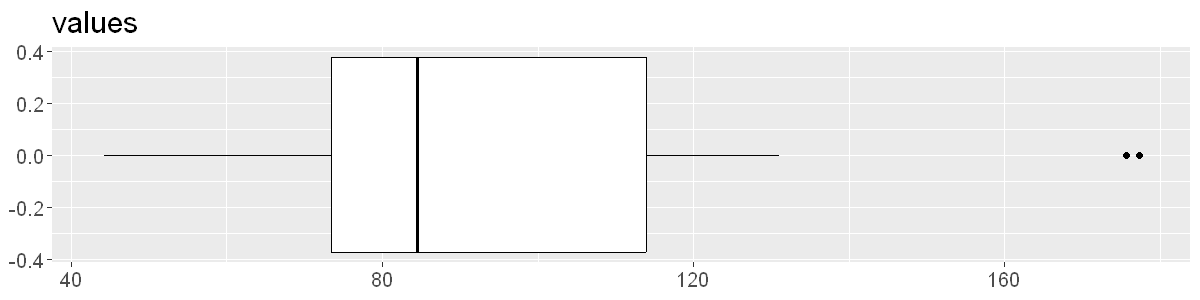

In [22]:
options(repr.plot.width = 10, repr.plot.height = 2.5)
gdp_data_NA <- na.omit(gdp_data)

sumtable(data_work, out="return", summ=summ)

ggplot(gdp_data_NA, aes(x=productivity)) +
        ggtitle("values") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

Data jsou reprezentovaná v procentech, které reprezentují poměr k průměru EU, který je nastaven na 100 %. Tudíž:<br>
115% - produktivita práce na osobu v zemi je o 15 % vyšší než průměr EU<br>
&nbsp;&nbsp;90% - produktivita práce na osobu v zemi je o 10 % nižší než průměr EU<br>
Nekteré hodnoty v datasetu chybí, proto je nejspíše průměrná hodnota jen 95 %.<br>

Směrodatná odchylka a IQR jsou vysoké, což naznačuje, že podmínky se v jednotlivých zemích značně liší. Velký rozdíl minimální a maximální hodnoty zdůrazňují přítomnost odlehlých hodnot, což mohou být země s velice nízkou nebo vysokou produktivitou.
Šikmost naznačuje existenci zemí s vysokou a odlehlou produktivitou A špičatost poukazuje, že více zemí má nižší produktivitu. Ale obě hodnoty jsou relativně nízké, co by mohlo naznačovat normální rozdělení.

In [23]:
head(gdp_data[order(gdp_data$productivity, decreasing = TRUE), ], 3)

,geo,values,region,consumption,productivity
,<chr>,<dbl>,<chr>,<dbl>,<dbl>
17,IE,56800,WE,23887,177.3
22,LU,96230,WE,38424,175.7
3,BE,37960,WE,23799,131.0


Vysoká produktivita může naznačovat silnou ekonomickou výkonnost, vysokou efektivitu využívání zdrojů a potenciálně příznivé podnikatelské prostředí, které podporuje růst produktivity. U Lucemburska víme, že se jedná o jeho velký finanční sektor, to stejné by mohlo platit i u Irska.

,values,productivity
values,1.0000000,0.9220911
productivity,0.9220911,1.0000000



	Shapiro-Wilk normality test

data:  gdp_data$productivity
W = 0.93746, p-value = 0.06343


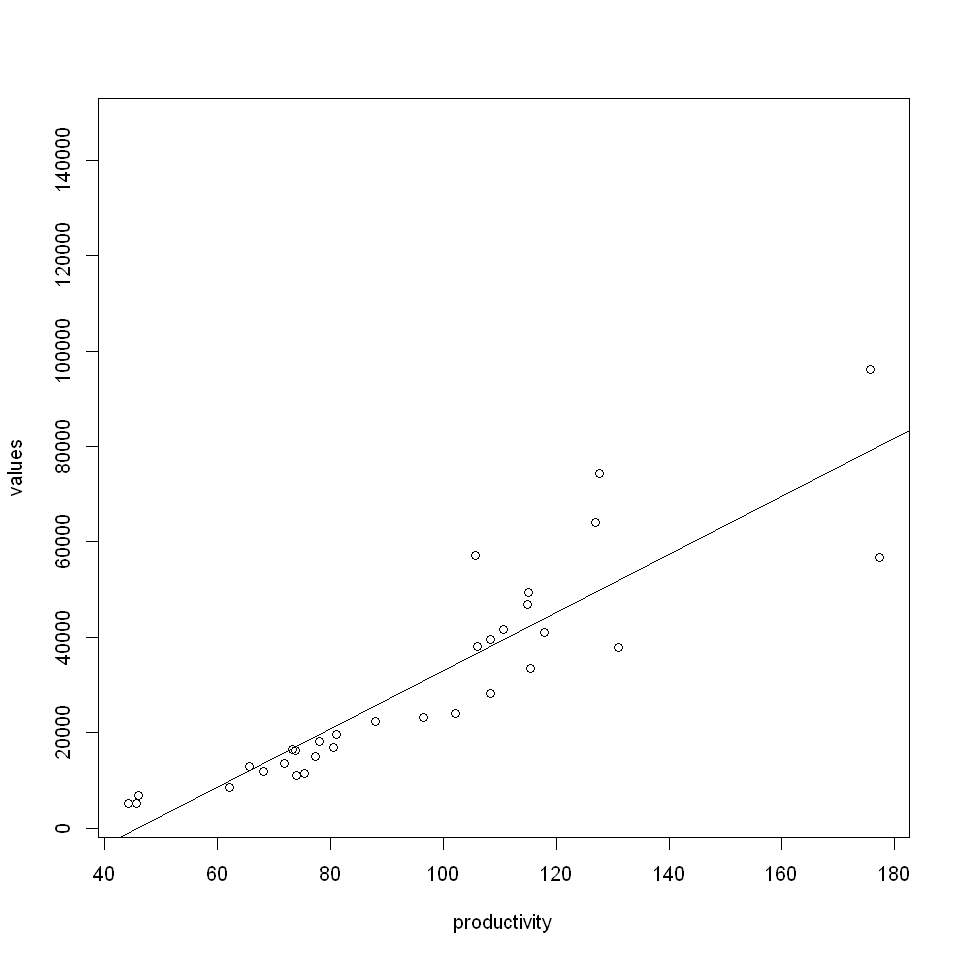

In [24]:
options(repr.plot.width = 8, repr.plot.height = 8)

cor(gdp_data_NA[c('values', 'productivity')])

plot(values~productivity, data = gdp_data)
abline(lm(values~productivity, data = gdp_data))
shapiro.test(gdp_data$productivity)

Znovu mám hodne vysokou korelaci (0.92), ukazuje to na silný vztah mezi HDP na obyvatele a produktivitou. Protože mám dva údaje které maji velmi vysokou korelaci je tady vysoká šance na multikolinearitu.<br>
Shapiro-Wilk test vyšel 0.063 proto normalitu nezamítáme.

In [25]:
summary(lm(values~productivity, data=gdp_data))


Call:
lm(formula = values ~ productivity, data = gdp_data)

Residuals:
   Min     1Q Median     3Q    Max 
-23322  -4843  -1512   4866  24412 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -27877.73    5510.38  -5.059 1.97e-05 ***
productivity    609.13      54.89  11.096 3.84e-12 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 9931 on 30 degrees of freedom
  (5 observations deleted due to missingness)
Multiple R-squared:  0.8041,	Adjusted R-squared:  0.7976 
F-statistic: 123.1 on 1 and 30 DF,  p-value: 3.844e-12


Tady vidím, že produktivita má statisticky významný vliv (3.84$e^{-12}$) na HDP na obyvatele a taky ho dobře vysvětluje (80.41 %).

### Export zboží a služeb
Jako poslední údaj použiju export. Vysoký export by měl vest k vyššímu ekonomickému růstu zvýšením produkce, zaměstnanosti a úrovní příjmů. Export taky umožňuje zemím dosáhnout většího trhu, tím pádem zvyšuje poptávku a produkci. Export generuje divize které lze použit k většímu dovozu který můžeme dále podporovat ekonomický růst.
Znovu se podívám na základní statistiky, korelaci a rozdělení.

In [26]:
data_export = get_eurostat("tet00003") # Exports of goods and services in % of GDP

data_export = data_export[!data_export$geo %in% c('EA', 'EA12', 'EA19', 'EA20', 'EU15', 'EU27_2020', 'EU28'), ]
data_export = data_export[data_export$TIME_PERIOD=='2016-01-01',] 
data_export = data_export[data_export$na_item=='P6',] # export zboží a služeb

data_export = select ( data_export, geo, values ) 
names(data_export) = c("geo", "export")
gdp_data = merge(x = gdp_data, y = data_export, by = "geo", all.x = TRUE)

head(gdp_data)

Table tet00003 cached at C:\Users\kulka\AppData\Local\Temp\Rtmpi2NjNx/eurostat/0ec107cf4feef6bbb228abc4916bdc3f.rds



,geo,values,region,consumption,productivity,export
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,AL,3730,EA,NA,NA,29.0
2,AT,40920,WE,23590,117.9,52.4
3,BE,37960,WE,23799,131.0,79.4
4,BG,6840,EA,3671,45.9,63.9
5,CY,22330,EA,17717,87.9,70.5
6,CZ,16790,EA,6061,80.6,79.1


Variable,Mean,Sd,Min,Pctile[25],Median,Pctile[75],Max,IQR,Skewness,Kurtosis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
export,60,35,23,36,49,75,191,39,1.9,4


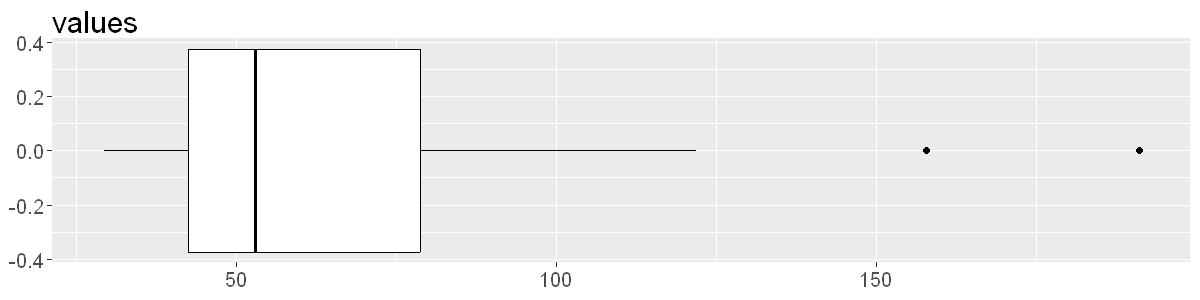

In [27]:
options(repr.plot.width = 10, repr.plot.height = 2.5)
gdp_data_NA <- na.omit(gdp_data)

sumtable(data_export, out="return", summ=summ)

ggplot(gdp_data_NA, aes(x=export)) +
        ggtitle("values") +
        geom_boxplot(color="black", show.legend=F) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

Střední hodnota a medián ukazuje, že významná část HDP zemí pochází z exportu. Podle vysoké směrodatné odchylky, velkého rozdílu mezi minimem existuji značně rozdílí ve velkosti exportu mezi zeměmi.<br>
Pozitivní šikmost a vysoká špičatost naznačují, že většina zemí má nízký export. Ale podle vysoké maximální hodnoty a kladné šikmosti existují země s velmi velkým exportem.

In [28]:
head(gdp_data[order(gdp_data$export, decreasing = TRUE), ], 2)

,geo,values,region,consumption,productivity,export
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
22,LU,96230,WE,38424,175.7,191.1
26,MT,23190,WE,12920,96.5,157.8


Outliery mohou být malými ekonomikami s velkými objemy obchodu nebo specializované na export. Lucembursko a Maltu jsme si ukázali v počáteční časti jako daňové ráje které se soustředí na finanční odvětí.

,values,export
values,1.0000000,0.4045656
export,0.4045656,1.0000000



	Shapiro-Wilk normality test

data:  gdp_data$export
W = 0.79914, p-value = 1.566e-05


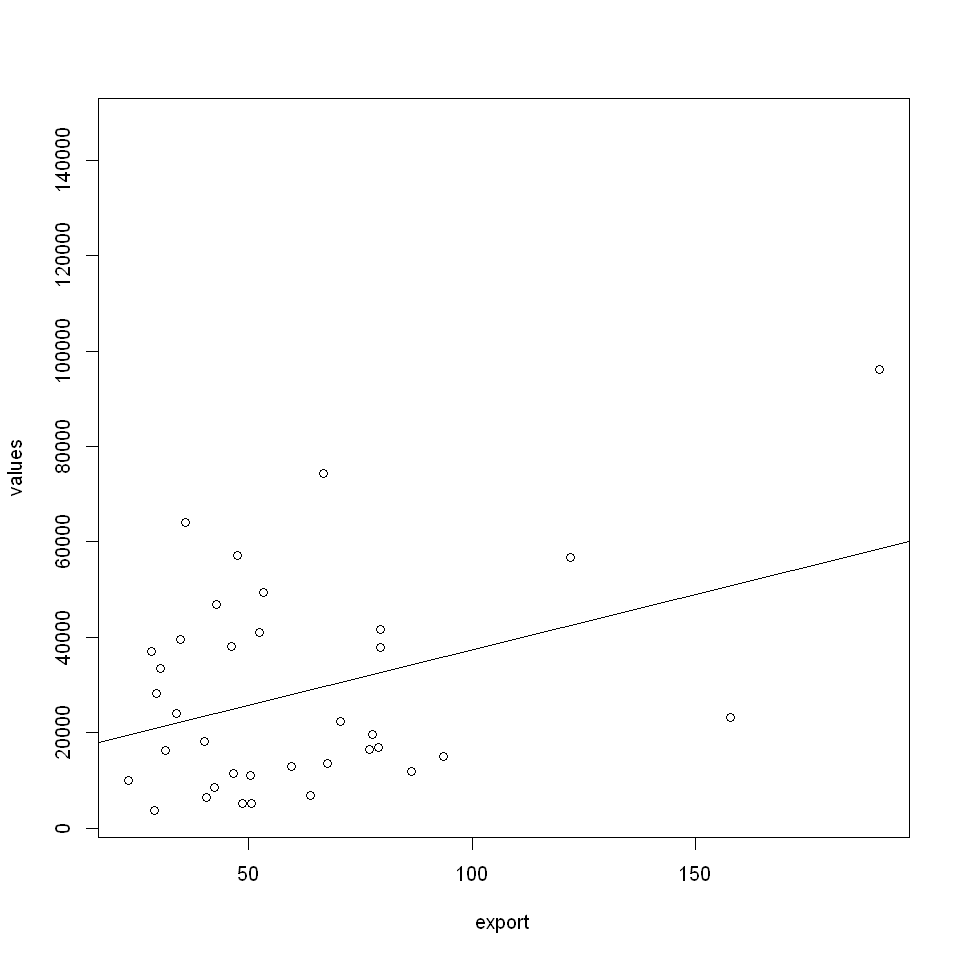

In [29]:
options(repr.plot.width = 8, repr.plot.height = 8)

cor(gdp_data_NA[c('values', 'export')])

plot(values~export, data = gdp_data)
abline(lm(values~export, data = gdp_data))
shapiro.test(gdp_data$export)

Pozitivní korelace (0.40) mezi exportem a HDP na obyvatele naznačuje lineární vztah mezi nimi, ale není moc silný. <br>
Shapiro-Wilk test má velmi malou hodnotu a proto zamítám normalitu rozdělení.

In [30]:
summary(lm(values~export, data=gdp_data))


Call:
lm(formula = values ~ export, data = gdp_data)

Residuals:
   Min     1Q Median     3Q    Max 
-27573 -15801  -6731  14462  44670 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) 14047.86    6875.15   2.043   0.0488 *
export        232.67      97.22   2.393   0.0224 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 20510 on 34 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.1442,	Adjusted R-squared:  0.119 
F-statistic: 5.727 on 1 and 34 DF,  p-value: 0.02237


Export vysvětluje jenom malou část (14.42 %) HDP na obyvatele ale má statistický významný vliv (0.0224) na nej, i když jenom těsně.

## Model

Teď budu zkoumat vztahy HDP mezi regresory na různých modelech a budu se snažit najít ten nejlepší.

### Zakladní model

Vytvorím lineární regresni model a budu ho postupne upravovat. Zkontroluji podmínky, multikolinearitu a koeficienty.

In [31]:
gdp_data_NA <- na.omit(gdp_data)
fit_lin = (lm(values ~ region + consumption + productivity + export, data = gdp_data_NA))
summary(fit_lin)


Call:
lm(formula = values ~ region + consumption + productivity + export, 
    data = gdp_data_NA)

Residuals:
   Min     1Q Median     3Q    Max 
-11938  -1676     99   2798   8400 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -1.469e+04  3.522e+03  -4.172 0.000318 ***
regionWE     -5.215e+03  3.342e+03  -1.560 0.131310    
consumption   1.736e+00  2.246e-01   7.727  4.4e-08 ***
productivity  1.329e+02  7.207e+01   1.844 0.077069 .  
export        9.258e+01  2.852e+01   3.246 0.003319 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4601 on 25 degrees of freedom
Multiple R-squared:  0.9568,	Adjusted R-squared:  0.9499 
F-statistic: 138.5 on 4 and 25 DF,  p-value: < 2.2e-16


Vidím, že produktivita nená moc vliv na HDP, proto bych ji mohl potenciálně vyškrtnou.

In [32]:
cor(model.matrix(fit_lin))

Warning message in cor(model.matrix(fit_lin)):
"the standard deviation is zero"


,(Intercept),regionWE,consumption,productivity,export
(Intercept),1,NA,NA,NA,NA
regionWE,NA,1.0000000,0.8431554,0.8133097,0.1241520
consumption,NA,0.8431554,1.0000000,0.8945750,0.2008191
productivity,NA,0.8133097,0.8945750,1.0000000,0.4061628
export,NA,0.1241520,0.2008191,0.4061628,1.0000000


Vidím, že regiony, spotřeba a produktivita jsou všechny navzájem silně korelované. Je velká šance, že tady bude existovat multikolinearita. Vypočítám si proto faktor zvětšení rozptylu.

In [33]:
round(vif(fit_lin),3)

region  consumption productivity       export 
       3.941        6.743        7.732        1.523

Faktor produktivity je velice vysoký, v modelu nemá moc velký vliv, a proto vyzkouším jestli bych ji mohl z modelu odstranit.

In [34]:
fit_lin_vif = (lm(values ~ region + consumption + export, data = gdp_data_NA))
summary(fit_lin_vif)


Call:
lm(formula = values ~ region + consumption + export, data = gdp_data_NA)

Residuals:
     Min       1Q   Median       3Q      Max 
-12600.6  -1865.7    861.7   2612.2   7893.6 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -9446.378   2168.390  -4.356 0.000184 ***
regionWE    -3117.528   3284.944  -0.949 0.351341    
consumption     2.020      0.171  11.814 5.92e-12 ***
export        121.904     24.746   4.926 4.08e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4808 on 26 degrees of freedom
Multiple R-squared:  0.9509,	Adjusted R-squared:  0.9453 
F-statistic:   168 on 3 and 26 DF,  p-value: < 2.2e-16


Odstraněním produktivity se mi snížila vysvětlovaná proměnná, koeficienty zůstaly stejné ale hodně se mi snížila chyba, z 4 601 na 12.52.  oveřit jestli 

In [35]:
anova(fit_lin_vif,fit_lin)
round(vif(fit_lin_vif),3)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,26,601148532,NA,NA,NA,NA
2,25,529174434,1,71974097,3.400301,0.07706852


region consumption      export 
      3.485       3.575       1.050

Test mi říka, že mezi modely není statistický významný rozdíl a proto můžu z modelu odstránit produktivitu.<br>
Zároveň jsem odstranil i multikolinearitu.<br>
Vyzkouším jestli se model dá ještě dále redukovat.

In [36]:
step(lm(values ~ 1, data=gdp_data_NA),scope=list(lower=~1,upper=~region + consumption + export))

Start:  AIC=596.83
values ~ 1

              Df  Sum of Sq        RSS    AIC
+ consumption  1 1.1047e+10 1.2061e+09 529.28
+ region       1 7.2352e+09 5.0177e+09 572.05
+ export       1 2.0055e+09 1.0247e+10 593.47
<none>                      1.2253e+10 596.83

Step:  AIC=529.28
values ~ consumption

              Df  Sum of Sq        RSS    AIC
+ export       1 5.8409e+08 6.2197e+08 511.42
<none>                      1.2061e+09 529.28
+ region       1 4.3813e+07 1.1622e+09 530.17
- consumption  1 1.1047e+10 1.2253e+10 596.83

Step:  AIC=511.42
values ~ consumption + export

              Df  Sum of Sq        RSS    AIC
<none>                      6.2197e+08 511.42
+ region       1   20824435 6.0115e+08 512.39
- export       1  584089523 1.2061e+09 529.28
- consumption  1 9625433713 1.0247e+10 593.47



Call:
lm(formula = values ~ consumption + export, data = gdp_data_NA)

Coefficients:
(Intercept)  consumption       export  
  -8965.321        1.883      123.918  


Nejlepší model obsahuje jenom regresory spotřeba a export. Interpretuji si tenhle model.

In [37]:
fit_lin_fin = (lm(values ~ consumption + export, data = gdp_data_NA))
summary(fit_lin_fin)


Call:
lm(formula = values ~ consumption + export, data = gdp_data_NA)

Residuals:
     Min       1Q   Median       3Q      Max 
-11728.8  -2416.7    562.2   2756.9   9157.7 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -8.965e+03  2.104e+03  -4.260 0.000222 ***
consumption  1.883e+00  9.212e-02  20.441  < 2e-16 ***
export       1.239e+02  2.461e+01   5.035 2.77e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4800 on 27 degrees of freedom
Multiple R-squared:  0.9492,	Adjusted R-squared:  0.9455 
F-statistic: 252.5 on 2 and 27 DF,  p-value: < 2.2e-16


Vzorec pro odhad HDP na obyvatele podle spotřeby a exportu:
$$ HDP  na  obyvatele = -8 965 + 1.883 \cdot consumption + 123.9 \cdot export $$

S nulovými regresormi je HDP na obyvatele -8 965 eur, záporné HDP v datasetu nenastalo i když je to možné. <br>
Každé euro spotřebované v domácnosti jednou dospělou osobou zvyšuje HDP na obyvatele o 1.883 eur.
A každé procento, které je tvořené z exportu z HDP zvyšuje HDP na obyvatele o 123.9 eur. 

Všechny koeficienty (${\beta}_0$, $consumption$, $export$) jsou statisticky významné při odhadu HDP na obyvatele. Standardni chyba je 4 800, v průměru se pozorované hodnoty odchylují od fittovaných přibližně o 4 800 eur. Model vysvětluje přibližně 94.92 % vysvětlované proměnné. Hodnoty Multiple $R^2$ a Adjusted $R^2$ jsou si podobné co taky poukazuje na dobrou kvalitu modelu. F-statistika s p-hodnotou mi ukazuje, že model je statisticky významný.

In [38]:
anova(fit_lin_fin, fit_lin_vif)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,27,621972967,NA,NA,NA,NA
2,26,601148532,1,20824435,0.9006681,0.3513412


Test mi ukazuje, že není statisticky významní rozdíl mezi modelami a tudíž redukce je možná.